In [29]:
import pandas as pd
df = pd.read_csv("hospital_readmissions_30k.csv")
df.head()

,patient_id,age,gender,blood_pressure,cholesterol,bmi,diabetes,hypertension,medication_count,length_of_stay,discharge_destination,readmitted_30_days
0,1,74,Other,130/72,240,31.5,Yes,No,5,1,Nursing_Facility,Yes
1,2,46,Female,120/92,292,36.3,No,No,4,3,Nursing_Facility,No
2,3,89,Other,135/78,153,30.3,No,Yes,1,1,Home,No
3,4,84,Female,123/80,153,31.5,No,Yes,3,10,Home,No
4,5,32,Other,135/84,205,18.4,No,Yes,6,4,Nursing_Facility,No


In [30]:
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   patient_id             30000 non-null  int64  
 1   age                    30000 non-null  int64  
 2   gender                 30000 non-null  object 
 3   blood_pressure         30000 non-null  object 
 4   cholesterol            30000 non-null  int64  
 5   bmi                    30000 non-null  float64
 6   diabetes               30000 non-null  object 
 7   hypertension           30000 non-null  object 
 8   medication_count       30000 non-null  int64  
 9   length_of_stay         30000 non-null  int64  
 10  discharge_destination  30000 non-null  object 
 11  readmitted_30_days     30000 non-null  object 
dtypes: float64(1), int64(5), object(6)
memory usage: 2.7+ MB


,0
patient_id,0
age,0
gender,0
blood_pressure,0
cholesterol,0
bmi,0
diabetes,0
hypertension,0
medication_count,0
length_of_stay,0


In [39]:
import warnings
warnings.filterwarnings('ignore')

In [31]:
df[['systolic', 'diastolic']] = df['blood_pressure'].str.split('/', expand=True).astype(int)
df = df.drop('blood_pressure', axis=1)
df.head()

,patient_id,age,gender,cholesterol,bmi,diabetes,hypertension,medication_count,length_of_stay,discharge_destination,readmitted_30_days,systolic,diastolic
0,1,74,Other,240,31.5,Yes,No,5,1,Nursing_Facility,Yes,130,72
1,2,46,Female,292,36.3,No,No,4,3,Nursing_Facility,No,120,92
2,3,89,Other,153,30.3,No,Yes,1,1,Home,No,135,78
3,4,84,Female,153,31.5,No,Yes,3,10,Home,No,123,80
4,5,32,Other,205,18.4,No,Yes,6,4,Nursing_Facility,No,135,84


In [32]:
df['readmitted_30_days'] = df['readmitted_30_days'].map({'Yes': 1, 'No': 0})
print(df['readmitted_30_days'].value_counts())


readmitted_30_days
0    26326
1     3674
Name: count, dtype: int64


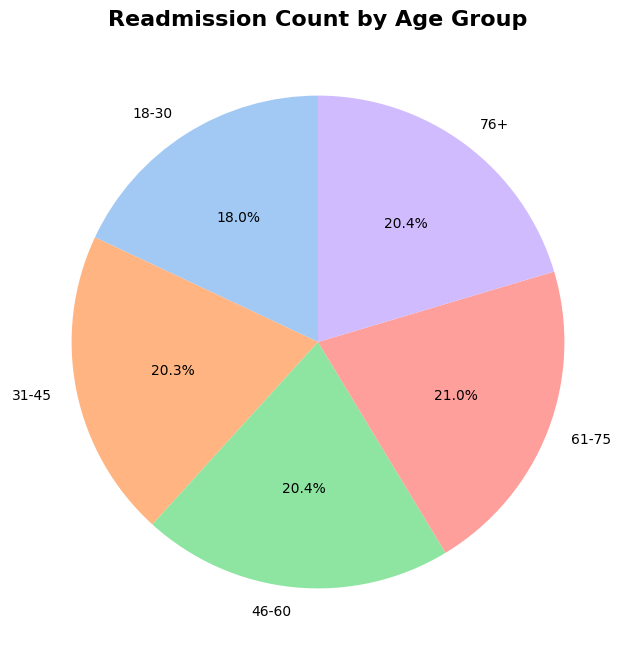

In [42]:
import warnings
warnings.filterwarnings('ignore')

age_data = df.groupby('age_group')['readmitted_30_days'].sum()

plt.figure(figsize=(8,8))
plt.pie(age_data.values,
        labels=age_data.index,
        autopct='%1.1f%%',
        colors=sns.color_palette('pastel'),
        startangle=90)
plt.title('Readmission Count by Age Group', fontsize=16, fontweight='bold')
plt.show()

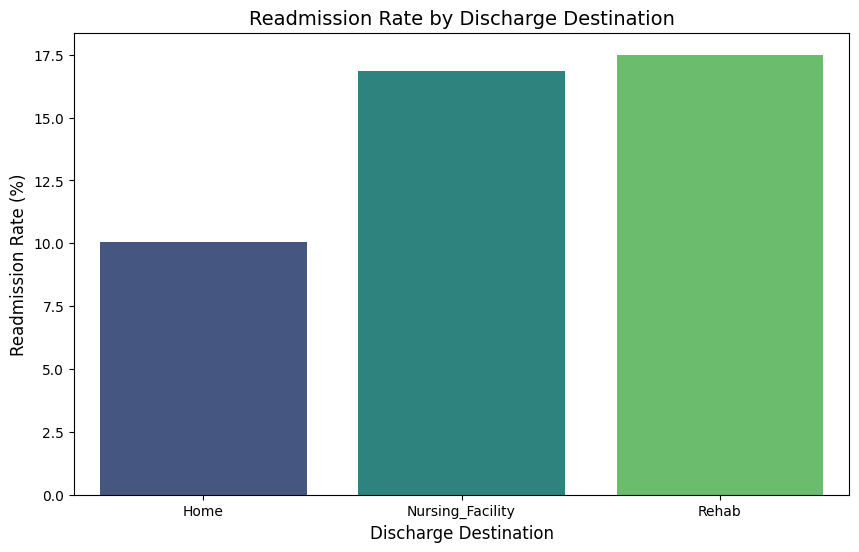

In [44]:
import warnings
warnings.filterwarnings('ignore')
plt.figure(figsize=(10,6))
discharge = df.groupby('discharge_destination')['readmitted_30_days'].mean() * 100
sns.barplot(x=discharge.index, y=discharge.values, palette='viridis')
plt.title('Readmission Rate by Discharge Destination', fontsize=14)
plt.xlabel('Discharge Destination', fontsize=12)
plt.ylabel('Readmission Rate (%)', fontsize=12)
plt.show()


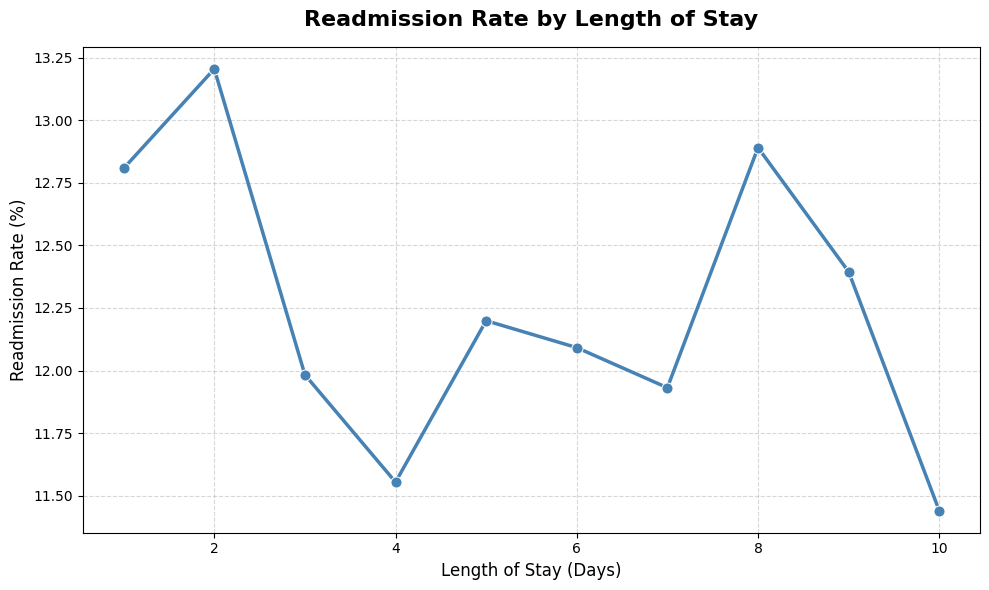

In [43]:
import warnings
warnings.filterwarnings('ignore')

plt.figure(figsize=(10,6))
stay = df.groupby('length_of_stay')['readmitted_30_days'].mean() * 100
sns.lineplot(x=stay.index, y=stay.values, marker='o', color='steelblue', linewidth=2.5, markersize=8)
plt.title('Readmission Rate by Length of Stay', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Length of Stay (Days)', fontsize=12)
plt.ylabel('Readmission Rate (%)', fontsize=12)
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

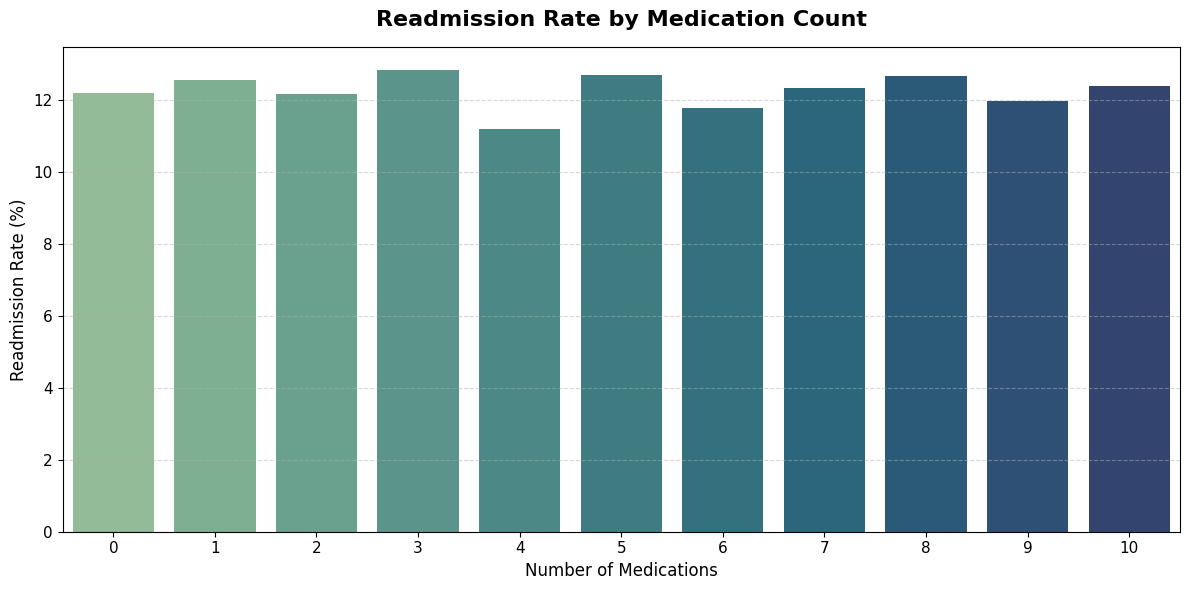

In [41]:
import warnings
warnings.filterwarnings('ignore')

plt.figure(figsize=(12,6))
med = df.groupby('medication_count')['readmitted_30_days'].mean() * 100
sns.barplot(x=med.index, y=med.values, palette='crest')
plt.title('Readmission Rate by Medication Count', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Number of Medications', fontsize=12)
plt.ylabel('Readmission Rate (%)', fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()